In [1]:
# SEASONAL AGRICULTURE PERFORMANCE ANALYSIS
# Major Project - AICTE
# ============================================================
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
# 2. LOAD DATASET
# ============================================================
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (4000, 28)


In [3]:
# 3. BASIC EXPLORATION
# ============================================================
print("\nFIRST 5 ROWS")
print(df.head())

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATA TYPES")
print(df.dtypes)

print("\nDATASET INFORMATION")
df.info()


FIRST 5 ROWS
   Farm_ID           State  District    Crop  Season  Farm_Area_Hectares  \
0  SF10001  Andhra Pradesh    Rajkot   Wheat  Kharif                0.53   
1  SF10002     Maharashtra  Nalgonda   Maize  Kharif                6.53   
2  SF10003       Telangana  Warangal  Pulses    Rabi                4.86   
3  SF10004       Telangana    Indore    Rice  Kharif                4.50   
4  SF10005       Karnataka  Ludhiana   Maize    Zaid                4.21   

   Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  ...  \
0        486.4               24.3          69.1                 5.8  ...   
1        855.4               25.7          78.4                 5.1  ...   
2        455.6               23.9          56.4                10.3  ...   
3        753.2               29.7          65.2                 6.3  ...   
4        101.6               34.1          55.2                 6.5  ...   

   Seed_Quality_Score  Yield_Tonnes_Ha  Production_Tonnes  \
0          

In [4]:
# 4. MISSING VALUES
# ============================================================
print("\nMISSING VALUES")

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

print(missing[missing["Missing Values"] > 0])

# Fill numerical missing values with median
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())



MISSING VALUES
                   Missing Values  Percentage
Rainfall_mm                    48         1.2
Soil_Moisture_pct              40         1.0
Yield_Tonnes_Ha                32         0.8


In [5]:
# 5. DUPLICATES
# ============================================================

print("\nDUPLICATES")

duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()


DUPLICATES
Duplicate rows: 0


In [6]:
# 6. DESCRIPTIVE STATISTICS
# ============================================================

print("\nDESCRIPTIVE STATISTICS")
print(df.describe().T)


DESCRIPTIVE STATISTICS
                                count           mean            std  \
Farm_Area_Hectares             4000.0       7.888265       4.223764   
Rainfall_mm                    4000.0     600.922825     287.193381   
Avg_Temperature_C              4000.0      26.818900       3.818180   
Humidity_pct                   4000.0      63.210500      11.960834   
Sunlight_Hours_Day             4000.0       7.323050       1.121186   
Soil_pH                        4000.0       6.701010       0.641461   
Soil_Moisture_pct              4000.0      26.507150       6.678837   
Nitrogen_kg_ha                 4000.0     120.250825      31.216452   
Phosphorus_kg_ha               4000.0      57.781850      17.015074   
Potassium_kg_ha                4000.0     104.760050      27.742681   
Fertilizer_kg_ha               4000.0     186.036000      60.260583   
Pesticide_Litre_ha             4000.0       5.070935       1.978879   
Seed_Quality_Score             4000.0       0.826138 

In [7]:
# 7. OUTLIER ANALYSIS
# ============================================================

print("\nOUTLIER ANALYSIS")

outlier_result = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_result.append([col, count])

outlier_table = pd.DataFrame(
    outlier_result,
    columns=["Column", "Outlier Count"]
)

print(outlier_table.sort_values(
    "Outlier Count",
    ascending=False
))



OUTLIER ANALYSIS
                           Column  Outlier Count
18                     Profit_INR            404
14              Production_Tonnes            333
20  Water_Efficiency_t_per_1000m3            322
13                Yield_Tonnes_Ha            302
19                  Water_Used_m3            276
17                    Revenue_INR            240
9                 Potassium_kg_ha             32
4              Sunlight_Hours_Day             26
8                Phosphorus_kg_ha             16
10               Fertilizer_kg_ha             15
7                  Nitrogen_kg_ha             10
21          Disease_Pest_Risk_pct             10
11             Pesticide_Litre_ha              8
3                    Humidity_pct              6
6               Soil_Moisture_pct              5
2               Avg_Temperature_C              2
0              Farm_Area_Hectares              0
1                     Rainfall_mm              0
5                         Soil_pH              0
12


VISUALIZATION: PAIRPLOT


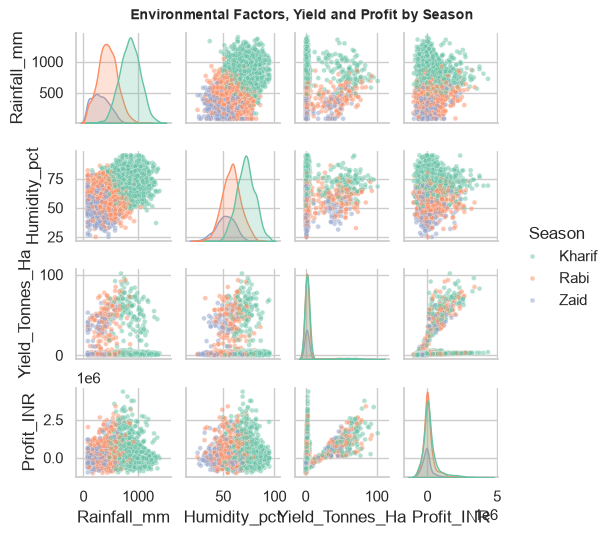

In [8]:
# 8. CLEAR VISUALIZATION - PAIRPLOT
# ============================================================

print("\nVISUALIZATION: PAIRPLOT")

pair_data = df[
    [
        "Rainfall_mm",
        "Humidity_pct",
        "Yield_Tonnes_Ha",
        "Profit_INR",
        "Season"
    ]
].dropna()

g = sns.pairplot(
    pair_data,
    vars=[
        "Rainfall_mm",
        "Humidity_pct",
        "Yield_Tonnes_Ha",
        "Profit_INR"
    ],
    hue="Season",
    palette="Set2",
    height=1.3,
    plot_kws={"s": 12, "alpha": 0.5},
    diag_kind="kde"
)

g.fig.suptitle(
    "Environmental Factors, Yield and Profit by Season",
    fontsize=10,
    fontweight="bold",
    y=1.02
)

plt.show()


VISUALIZATION: YIELD BY SEASON


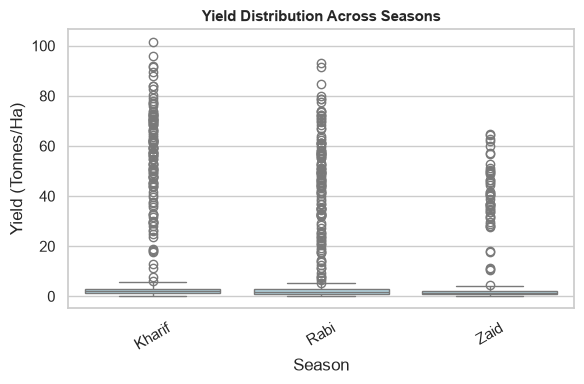

In [9]:
# 9. BOXPLOT - YIELD BY SEASON
# ============================================================

print("\nVISUALIZATION: YIELD BY SEASON")

plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    color="lightblue"
)

plt.title(
    "Yield Distribution Across Seasons",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



VISUALIZATION: PROFIT BY SEASON


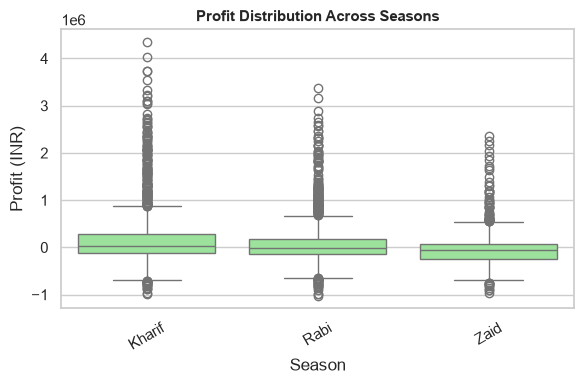

In [10]:
# 10. BOXPLOT - PROFIT BY SEASON
# ============================================================

print("\nVISUALIZATION: PROFIT BY SEASON")

plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="Season",
    y="Profit_INR",
    color="lightgreen"
)

plt.title(
    "Profit Distribution Across Seasons",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



AVERAGE YIELD BY SEASON
Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


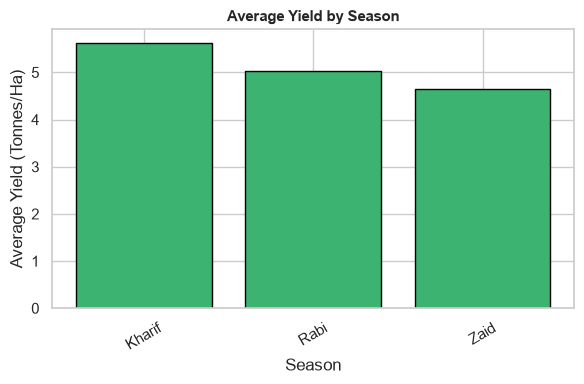

In [11]:
# 11. AVERAGE YIELD BY SEASON
# ============================================================

season_yield = (
    df.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAVERAGE YIELD BY SEASON")
print(season_yield)

plt.figure(figsize=(6, 4))

plt.bar(
    season_yield.index,
    season_yield.values,
    color="mediumseagreen",
    edgecolor="black"
)

plt.title(
    "Average Yield by Season",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



AVERAGE PROFIT BY SEASON
Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


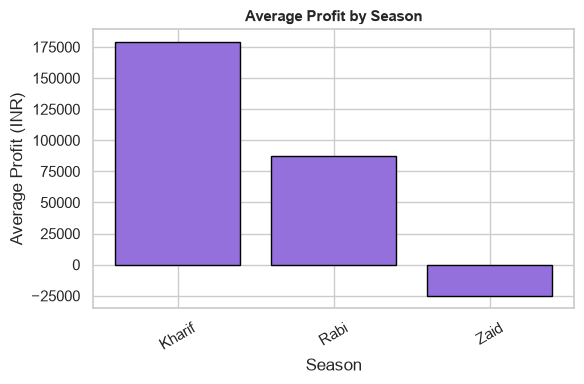

In [12]:
# 12. AVERAGE PROFIT BY SEASON
# ============================================================

season_profit = (
    df.groupby("Season")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAVERAGE PROFIT BY SEASON")
print(season_profit)

plt.figure(figsize=(6, 4))

plt.bar(
    season_profit.index,
    season_profit.values,
    color="mediumpurple",
    edgecolor="black"
)

plt.title(
    "Average Profit by Season",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


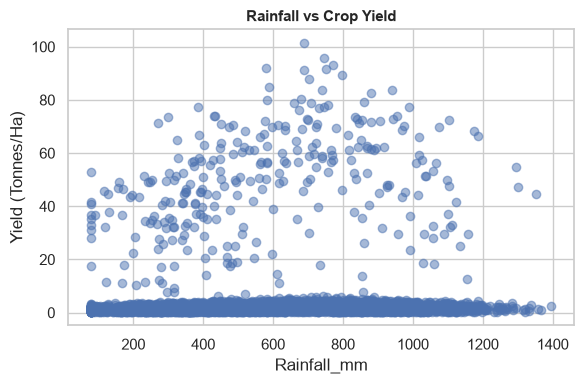

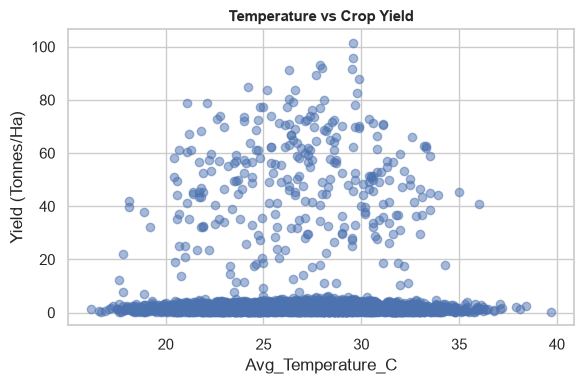

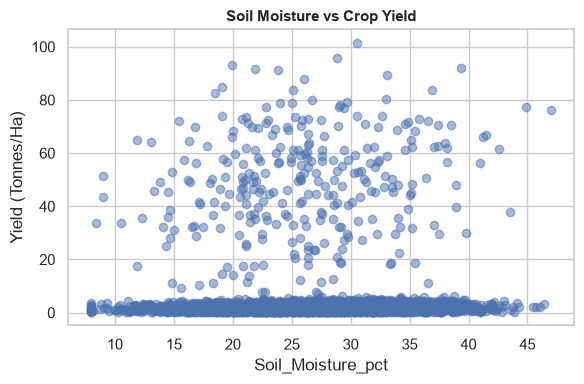

In [13]:
# 13. ENVIRONMENTAL FACTORS VS YIELD
# ============================================================

environmental_variables = [
    ("Rainfall_mm", "Rainfall vs Crop Yield"),
    ("Avg_Temperature_C", "Temperature vs Crop Yield"),
    ("Soil_Moisture_pct", "Soil Moisture vs Crop Yield")
]

for x, title in environmental_variables:

    plt.figure(figsize=(6, 4))

    plt.scatter(
        df[x],
        df["Yield_Tonnes_Ha"],
        alpha=0.5
    )

    plt.title(
        title,
        fontsize=11,
        fontweight="bold"
    )

    plt.xlabel(x)
    plt.ylabel("Yield (Tonnes/Ha)")
    plt.tight_layout()
    plt.show()


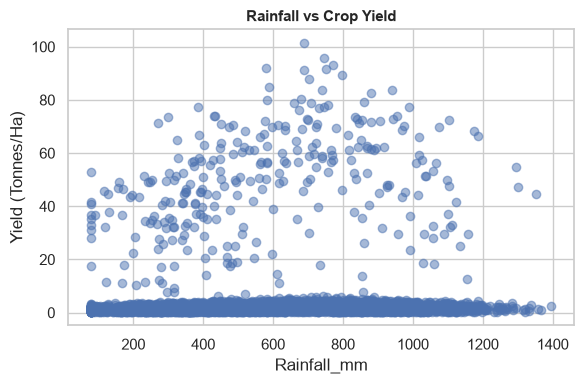

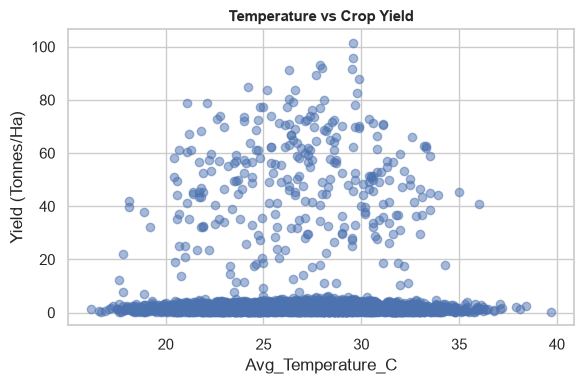

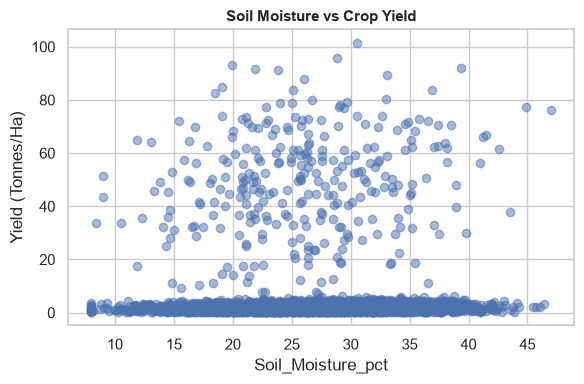

In [14]:
# 13. ENVIRONMENTAL FACTORS VS YIELD
# ============================================================

environmental_variables = [
    ("Rainfall_mm", "Rainfall vs Crop Yield"),
    ("Avg_Temperature_C", "Temperature vs Crop Yield"),
    ("Soil_Moisture_pct", "Soil Moisture vs Crop Yield")
]

for x, title in environmental_variables:

    plt.figure(figsize=(6, 4))

    plt.scatter(
        df[x],
        df["Yield_Tonnes_Ha"],
        alpha=0.5
    )

    plt.title(
        title,
        fontsize=11,
        fontweight="bold"
    )

    plt.xlabel(x)
    plt.ylabel("Yield (Tonnes/Ha)")
    plt.tight_layout()
    plt.show()


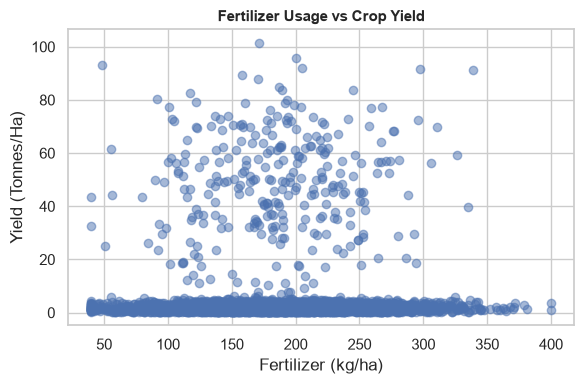

In [15]:
# 14. FERTILIZER VS YIELD
# ============================================================

plt.figure(figsize=(6, 4))

plt.scatter(
    df["Fertilizer_kg_ha"],
    df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title(
    "Fertilizer Usage vs Crop Yield",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()


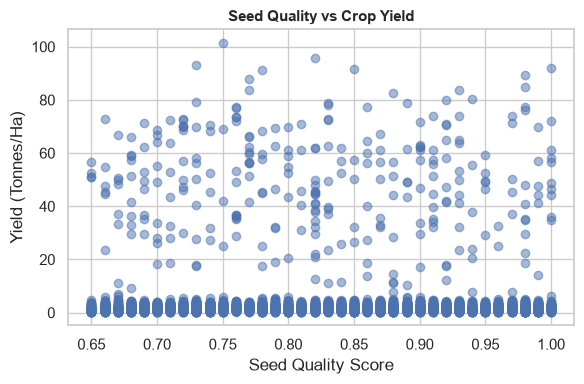

In [16]:
# 15. SEED QUALITY VS YIELD
# ============================================================

plt.figure(figsize=(6, 4))

plt.scatter(
    df["Seed_Quality_Score"],
    df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title(
    "Seed Quality vs Crop Yield",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Seed Quality Score")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

In [17]:
# 16. CORRELATION ANALYSIS
# ============================================================

correlation = df[numeric_columns].corr()

print("\nCORRELATION MATRIX")
print(correlation.round(2))


CORRELATION MATRIX
                               Farm_Area_Hectares  Rainfall_mm  \
Farm_Area_Hectares                           1.00         0.01   
Rainfall_mm                                  0.01         1.00   
Avg_Temperature_C                            0.04         0.20   
Humidity_pct                                 0.00         0.52   
Sunlight_Hours_Day                           0.00        -0.36   
Soil_pH                                      0.01         0.02   
Soil_Moisture_pct                            0.00         0.51   
Nitrogen_kg_ha                               0.01         0.01   
Phosphorus_kg_ha                            -0.01         0.02   
Potassium_kg_ha                              0.00         0.03   
Fertilizer_kg_ha                             0.01         0.02   
Pesticide_Litre_ha                          -0.01         0.00   
Seed_Quality_Score                           0.02        -0.02   
Yield_Tonnes_Ha                              0.03       

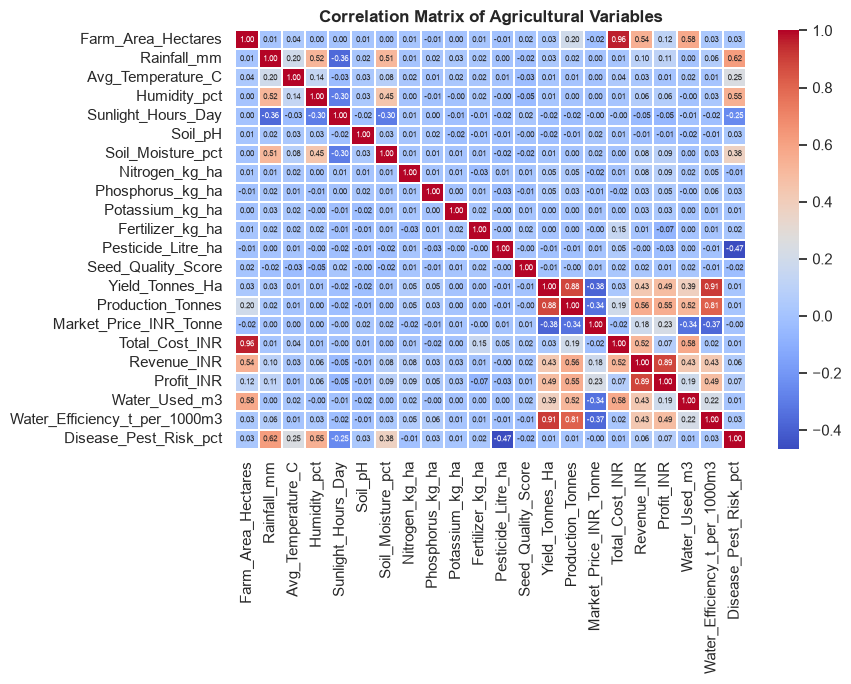

In [18]:
# 17. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    annot_kws={"size": 6}
)

plt.title(
    "Correlation Matrix of Agricultural Variables",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [19]:
# 18. STRONGEST VARIABLES RELATED TO YIELD
# ============================================================

yield_corr = (
    correlation["Yield_Tonnes_Ha"]
    .drop("Yield_Tonnes_Ha")
    .sort_values(key=abs, ascending=False)
)

print("\nVARIABLES RELATED TO YIELD")
print(yield_corr)



VARIABLES RELATED TO YIELD
Water_Efficiency_t_per_1000m3    0.912568
Production_Tonnes                0.882813
Profit_INR                       0.488466
Revenue_INR                      0.432152
Water_Used_m3                    0.386294
Market_Price_INR_Tonne          -0.382607
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Rainfall_mm                      0.030951
Total_Cost_INR                   0.030622
Farm_Area_Hectares               0.030203
Soil_pH                         -0.020672
Sunlight_Hours_Day              -0.015341
Disease_Pest_Risk_pct            0.014292
Humidity_pct                     0.012297
Soil_Moisture_pct                0.010999
Avg_Temperature_C                0.009996
Pesticide_Litre_ha              -0.007779
Seed_Quality_Score              -0.007209
Potassium_kg_ha                  0.003382
Fertilizer_kg_ha                 0.000018
Name: Yield_Tonnes_Ha, dtype: float64


In [20]:
# 19. STRONGEST VARIABLES RELATED TO PROFIT
# ============================================================

profit_corr = (
    correlation["Profit_INR"]
    .drop("Profit_INR")
    .sort_values(key=abs, ascending=False)
)

print("\nVARIABLES RELATED TO PROFIT")
print(profit_corr)



VARIABLES RELATED TO PROFIT
Revenue_INR                      0.887331
Production_Tonnes                0.554172
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.488466
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Farm_Area_Hectares               0.115241
Rainfall_mm                      0.107648
Soil_Moisture_pct                0.091281
Nitrogen_kg_ha                   0.085016
Fertilizer_kg_ha                -0.073542
Total_Cost_INR                   0.068356
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.063775
Sunlight_Hours_Day              -0.054822
Phosphorus_kg_ha                 0.049747
Potassium_kg_ha                  0.031192
Pesticide_Litre_ha              -0.025705
Soil_pH                         -0.013145
Seed_Quality_Score               0.010438
Avg_Temperature_C                0.009043
Name: Profit_INR, dtype: float64


In [21]:
# 20. CROP-WISE ANALYSIS
# ============================================================

crop_summary = df.groupby("Crop").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Production=("Production_Tonnes", "sum")
)

crop_summary = crop_summary.sort_values(
    "Average_Profit",
    ascending=False
)

print("\nCROP-WISE PERFORMANCE")
print(crop_summary)


CROP-WISE PERFORMANCE
           Average_Yield  Average_Profit  Total_Production
Crop                                                      
Sugarcane      46.642361   817187.986885         119685.97
Chilli          1.542767   750878.342233           5101.75
Cotton          1.229783   124546.915354           4773.10
Groundnut       1.322901    44858.120283           4094.07
Pulses          0.921512    -4238.052419           3671.10
Maize           2.710036   -83978.326679          12001.40
Rice            2.431304  -102213.504348          13309.15
Wheat           2.108013  -123398.337134          10348.30


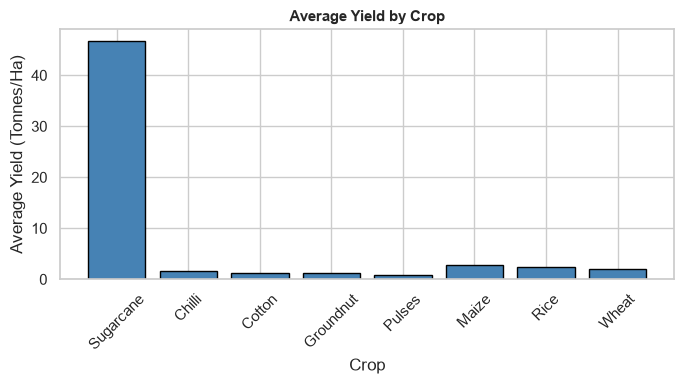

In [22]:
# 21. CROP-WISE YIELD
# ============================================================

plt.figure(figsize=(7, 4))

plt.bar(
    crop_summary.index,
    crop_summary["Average_Yield"],
    color="steelblue",
    edgecolor="black"
)

plt.title(
    "Average Yield by Crop",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


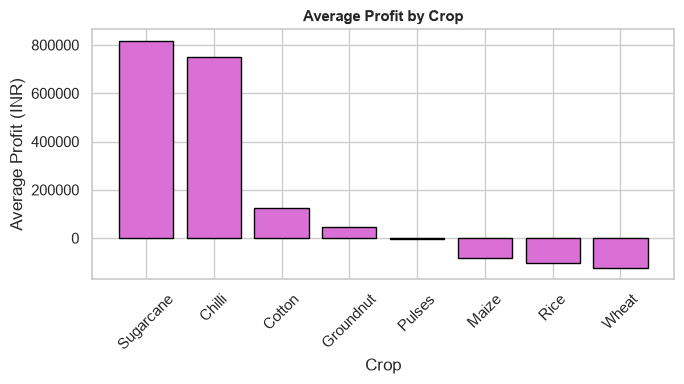

In [23]:
# 22. CROP-WISE PROFIT
# ============================================================

plt.figure(figsize=(7, 4))

plt.bar(
    crop_summary.index,
    crop_summary["Average_Profit"],
    color="orchid",
    edgecolor="black"
)

plt.title(
    "Average Profit by Crop",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


TOP 10 STATES BY AVERAGE PROFIT
State
Punjab            136025.636364
Maharashtra       135428.855469
Karnataka         119422.335378
Tamil Nadu        117744.748454
Gujarat           117568.235656
Telangana         108829.616279
Madhya Pradesh     86840.756539
Andhra Pradesh     73453.527410
Name: Average_Profit, dtype: float64


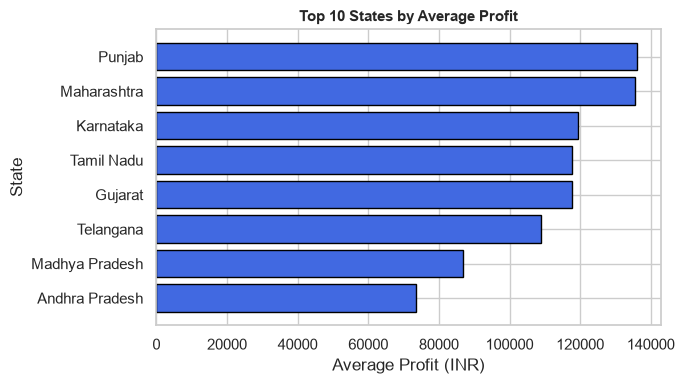

In [24]:
# 23. STATE-WISE ANALYSIS
# ============================================================

state_summary = df.groupby("State").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean")
)

print("\nTOP 10 STATES BY AVERAGE PROFIT")

top_states = (
    state_summary["Average_Profit"]
    .sort_values(ascending=False)
    .head(10)
)

print(top_states)

plt.figure(figsize=(7, 4))

plt.barh(
    top_states.index[::-1],
    top_states.values[::-1],
    color="royalblue",
    edgecolor="black"
)

plt.title(
    "Top 10 States by Average Profit",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Average Profit (INR)")
plt.ylabel("State")
plt.tight_layout()
plt.show()



IRRIGATION METHOD PERFORMANCE
                   Average_Yield  Average_Profit
Irrigation_Method                               
Drip                    6.577989   219625.997814
Flood                   4.863977    73354.022901
Rainfed                 4.602142    79050.365034
Sprinkler               5.160627    91121.079019


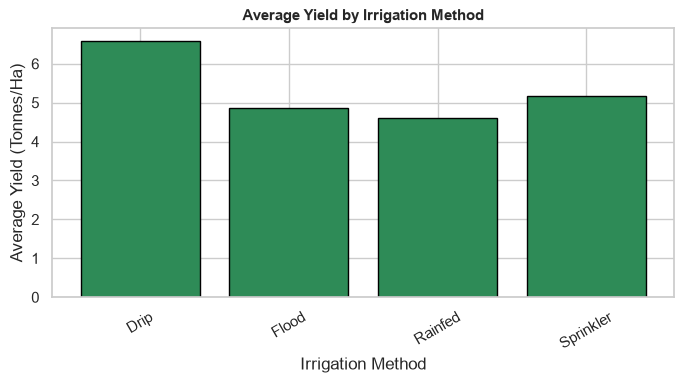

In [25]:
# 24. IRRIGATION ANALYSIS
# ============================================================

irrigation = df.groupby("Irrigation_Method").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean")
)

print("\nIRRIGATION METHOD PERFORMANCE")
print(irrigation)

plt.figure(figsize=(7, 4))

plt.bar(
    irrigation.index,
    irrigation["Average_Yield"],
    color="seagreen",
    edgecolor="black"
)

plt.title(
    "Average Yield by Irrigation Method",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



WATER EFFICIENCY BY SEASON
Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64


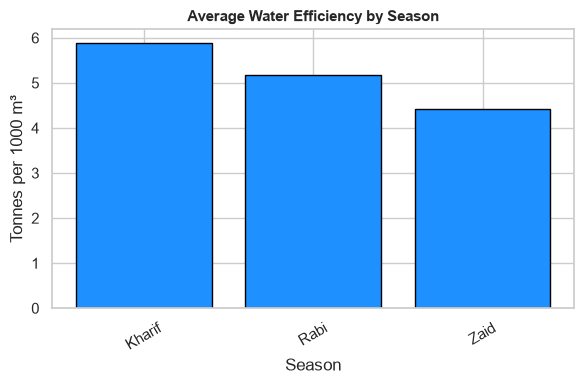

In [26]:
# 25. WATER EFFICIENCY BY SEASON
# ============================================================

water = (
    df.groupby("Season")
    ["Water_Efficiency_t_per_1000m3"]
    .mean()
    .sort_values(ascending=False)
)

print("\nWATER EFFICIENCY BY SEASON")
print(water)

plt.figure(figsize=(6, 4))

plt.bar(
    water.index,
    water.values,
    color="dodgerblue",
    edgecolor="black"
)

plt.title(
    "Average Water Efficiency by Season",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



DISEASE/PEST RISK BY SEASON
Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64


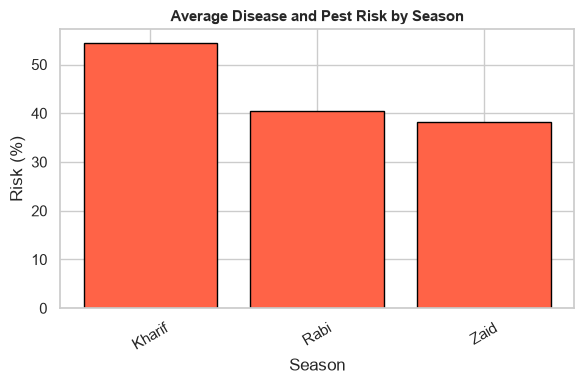

In [27]:
# 26. DISEASE AND PEST RISK
# ============================================================

risk = (
    df.groupby("Season")
    ["Disease_Pest_Risk_pct"]
    .mean()
    .sort_values(ascending=False)
)

print("\nDISEASE/PEST RISK BY SEASON")
print(risk)

plt.figure(figsize=(6, 4))

plt.bar(
    risk.index,
    risk.values,
    color="tomato",
    edgecolor="black"
)

plt.title(
    "Average Disease and Pest Risk by Season",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


AVERAGE YIELD BY SEASON AND CROP
Crop    Chilli  Cotton  Groundnut  Maize  Pulses  Rice  Sugarcane  Wheat
Season                                                                  
Kharif    1.73    1.37       1.48   2.97    1.04  2.70      53.46   2.25
Rabi      1.47    1.20       1.23   2.60    0.88  2.32      43.29   2.06
Zaid      1.20    0.96       1.04   2.29    0.67  1.90      38.42   1.75


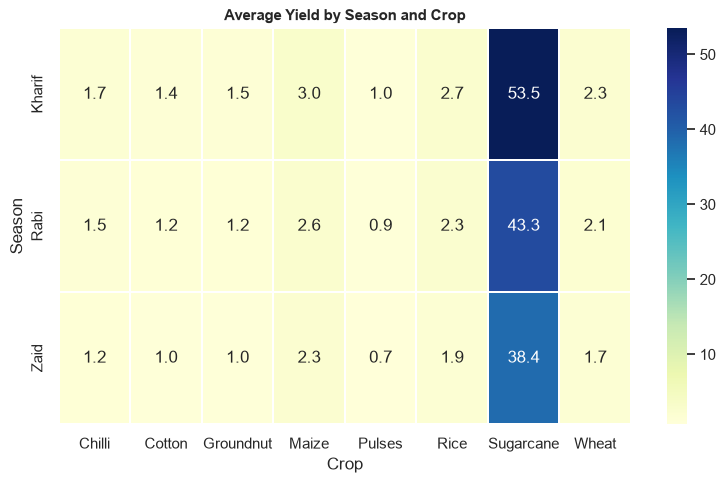

In [28]:
# 27. SEASON × CROP HEATMAP
# ============================================================

season_crop = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Season",
    columns="Crop",
    aggfunc="mean"
)

print("\nAVERAGE YIELD BY SEASON AND CROP")
print(season_crop.round(2))

plt.figure(figsize=(8, 5))

sns.heatmap(
    season_crop,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.3
)

plt.title(
    "Average Yield by Season and Crop",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Crop")
plt.ylabel("Season")
plt.tight_layout()
plt.show()



PROFIT MARGIN BY SEASON
Season
Kharif   -38.644541
Rabi     -44.267645
Zaid     -69.354573
Name: Profit_Margin_pct, dtype: float64


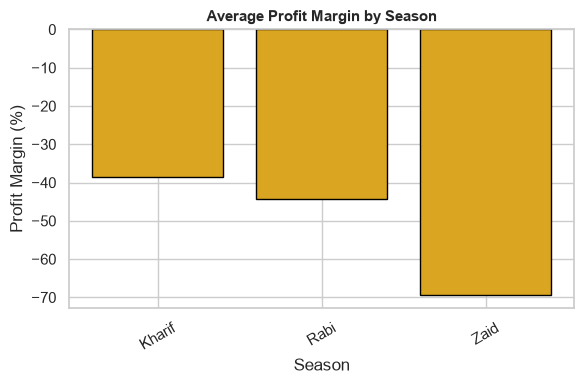

In [29]:
# 28. PROFIT MARGIN
# ============================================================

df["Profit_Margin_pct"] = np.where(
    df["Revenue_INR"] != 0,
    df["Profit_INR"] / df["Revenue_INR"] * 100,
    0
)

season_margin = (
    df.groupby("Season")
    ["Profit_Margin_pct"]
    .mean()
    .sort_values(ascending=False)
)

print("\nPROFIT MARGIN BY SEASON")
print(season_margin)

plt.figure(figsize=(6, 4))

plt.bar(
    season_margin.index,
    season_margin.values,
    color="goldenrod",
    edgecolor="black"
)

plt.title(
    "Average Profit Margin by Season",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [30]:
# 29. TOP PERFORMING FARM
# ============================================================

best_farm = df.loc[df["Profit_INR"].idxmax()]

print("\nBEST PERFORMING FARM")

print("Farm ID:", best_farm["Farm_ID"])
print("State:", best_farm["State"])
print("District:", best_farm["District"])
print("Crop:", best_farm["Crop"])
print("Season:", best_farm["Season"])
print(
    "Yield:",
    round(best_farm["Yield_Tonnes_Ha"], 2),
    "Tonnes/Ha"
)
print(
    "Profit:",
    round(best_farm["Profit_INR"], 2),
    "INR"
)



BEST PERFORMING FARM
Farm ID: SF12237
State: Punjab
District: Rajkot
Crop: Chilli
Season: Kharif
Yield: 3.9 Tonnes/Ha
Profit: 4345421 INR


In [31]:
# 30. LOSS-MAKING FARMS
# ============================================================

loss_making = df[df["Profit_INR"] < 0]

loss_percentage = (
    len(loss_making) / len(df) * 100
)

print("\nLOSS-MAKING FARMS")
print("Number:", len(loss_making))
print(
    "Percentage:",
    round(loss_percentage, 2),
    "%"
)



LOSS-MAKING FARMS
Number: 1966
Percentage: 49.15 %


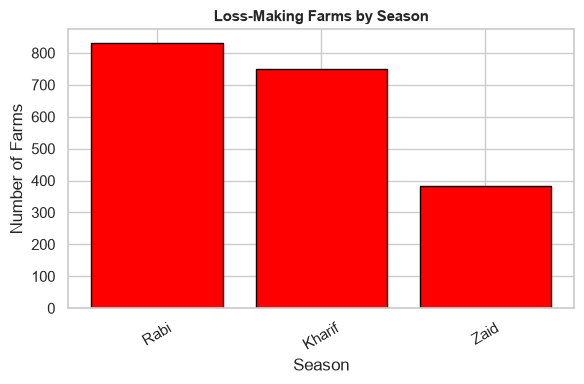

In [32]:
# 31. LOSS-MAKING FARMS BY SEASON
# ============================================================

loss_season = loss_making["Season"].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(
    loss_season.index,
    loss_season.values,
    color="red",
    edgecolor="black"
)

plt.title(
    "Loss-Making Farms by Season",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [33]:
# 32. KEY INSIGHTS
# ============================================================

print("\nKEY INSIGHTS")

print(
    "1. Highest average yield season:",
    season_yield.idxmax()
)

print(
    "2. Highest average profit season:",
    season_profit.idxmax()
)

print(
    "3. Most profitable crop:",
    crop_summary["Average_Profit"].idxmax()
)

print(
    "4. Highest water-efficiency season:",
    water.idxmax()
)

print(
    "5. Highest disease/pest-risk season:",
    risk.idxmax()
)

print(
    "6. Highest-production crop:",
    crop_summary["Total_Production"].idxmax()
)

print(
    "7. Best irrigation method by yield:",
    irrigation["Average_Yield"].idxmax()
)

print(
    "8. Highest profit-margin season:",
    season_margin.idxmax()
)

print(
    "9. Highest individual profit:",
    round(df["Profit_INR"].max(), 2),
    "INR"
)

print(
    "10. Highest individual yield:",
    round(df["Yield_Tonnes_Ha"].max(), 2),
    "Tonnes/Ha"
)

print(
    "11. Loss-making records:",
    len(loss_making)
)



KEY INSIGHTS
1. Highest average yield season: Kharif
2. Highest average profit season: Kharif
3. Most profitable crop: Sugarcane
4. Highest water-efficiency season: Kharif
5. Highest disease/pest-risk season: Kharif
6. Highest-production crop: Sugarcane
7. Best irrigation method by yield: Drip
8. Highest profit-margin season: Kharif
9. Highest individual profit: 4345421 INR
10. Highest individual yield: 101.44 Tonnes/Ha
11. Loss-making records: 1966


In [34]:
# 33. RECOMMENDATIONS
# ============================================================

print("\nRECOMMENDATIONS")

print(
    "1. Focus planning on seasons with higher yield and profit."
)

print(
    "2. Select crops using both yield and profitability."
)

print(
    "3. Promote efficient irrigation methods."
)

print(
    "4. Monitor disease and pest risk during high-risk seasons."
)

print(
    "5. Use rainfall, temperature and soil moisture "
    "for seasonal planning."
)

print(
    "6. Control production costs to improve profitability."
)

print(
    "7. Use state-wise performance differences "
    "for better agricultural planning."
)

print(
    "8. Improve resource management based on historical data."
)



RECOMMENDATIONS
1. Focus planning on seasons with higher yield and profit.
2. Select crops using both yield and profitability.
3. Promote efficient irrigation methods.
4. Monitor disease and pest risk during high-risk seasons.
5. Use rainfall, temperature and soil moisture for seasonal planning.
6. Control production costs to improve profitability.
7. Use state-wise performance differences for better agricultural planning.
8. Improve resource management based on historical data.


In [35]:
# 34. FINAL CONCLUSION
# ============================================================

print("\nFINAL CONCLUSION")

print(
    "Agricultural performance varies across seasons, "
    "crops and regions."
)

print(
    "The analysis examined yield, production, revenue, "
    "cost, profit, water efficiency and disease/pest risk."
)

print(
    "Environmental factors such as rainfall, temperature "
    "and soil moisture were compared with crop yield."
)

print(
    "Boxplots helped identify seasonal variation and spread, "
    "while the pairplot showed relationships among important "
    "environmental and economic variables."
)

print(
    "The findings can support better crop selection, "
    "resource management and seasonal agricultural planning."
)

print("\nANALYSIS COMPLETED SUCCESSFULLY")


FINAL CONCLUSION
Agricultural performance varies across seasons, crops and regions.
The analysis examined yield, production, revenue, cost, profit, water efficiency and disease/pest risk.
Environmental factors such as rainfall, temperature and soil moisture were compared with crop yield.
Boxplots helped identify seasonal variation and spread, while the pairplot showed relationships among important environmental and economic variables.
The findings can support better crop selection, resource management and seasonal agricultural planning.

ANALYSIS COMPLETED SUCCESSFULLY
